# Chart: Model Flexibility and Varying Data Set Sizes


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/chart_model_flexibility_and_varying_data_set_sizes.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/chart_model_flexibility_and_varying_data_set_sizes.ipynb)



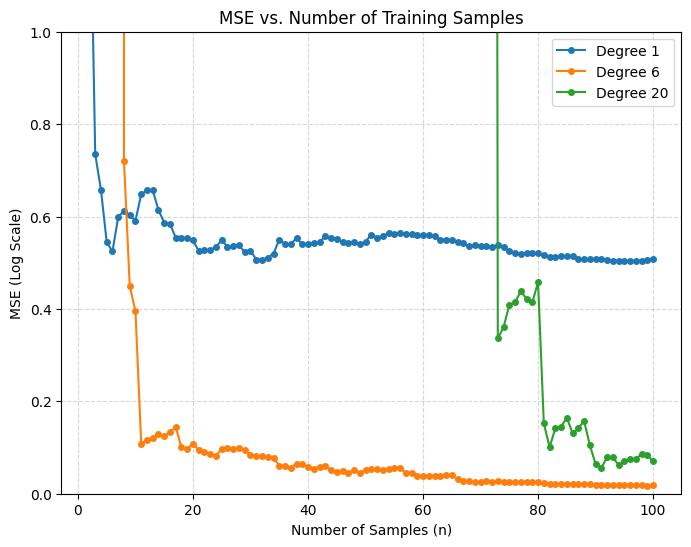

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Define ground truth function
def f(x):
    return x + np.sin(x)

# Generate ground truth line
xs_ground_truth = np.linspace(-5, 5, 200)
ys_ground_truth = f(xs_ground_truth)

# noisy samples
N_TOTAL = 100
x_samples = np.random.uniform(-5, 5, N_TOTAL)
y_samples = f(x_samples) + np.random.normal(scale=0.5, size=N_TOTAL)

# 2. Setup for computation
degrees = [1, 6, 20]
results = {d: [] for d in degrees}

# 3. Iterate through degrees and sample sizes
for d in degrees:
    sample_range = range(d + 1, N_TOTAL + 1)
    for n in sample_range:
        # Take prefix of samples
        xn = x_samples[:n]
        yn = y_samples[:n]

        # Fit polynomial
        coeffs = np.polyfit(xn, yn, d)
        model = np.poly1d(coeffs)

        # Compute MSE against ground truth at the sample locations used for training
        # Note: The prompt asks for MSE for 'ground truth points being used'
        mse = mean_squared_error(f(xs_ground_truth), model(xs_ground_truth))
        results[d].append((n, mse))

# 4. Plotting
plt.figure(figsize=(8, 6))
for d in degrees:
    n_vals, mse_vals = zip(*results[d])
    plt.plot(n_vals, mse_vals, label=f'Degree {d}', marker='o', markersize=4)

# plt.yscale('log')
plt.title("MSE vs. Number of Training Samples")
plt.xlabel("Number of Samples (n)")
plt.ylabel("MSE (Log Scale)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()